<a href="https://colab.research.google.com/github/chandinignits-del/ML-Lab-GNITS-2026-27/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Linear Regression** is a supervised machine learning algorithm used to predict continuous values by modelling the relationship between input features and output using a best-fit straight line.

Predicts continuous outputs such as prices, scores, or sales values.
Learns the relationship between independent variables and the dependent variable from training data.
**Types**
Linear Regression is mainly of two types:

**1. Simple Linear Regression**
Simple Linear Regression is a supervised learning algorithm used to predict a continuous target variable using a single input feature. It assumes a linear relationship between the input and output and represents it using a straight line.
**Step 1: Import Libraries**

Import the required libraries NumPy for numerical operations and Matplotlib for visualization.
**Step 2: Implement Simple Linear Regression Class**
Define a SimpleLinearRegression class to model the relationship between a single input feature and a target variable using a linear equation.

__init__ method: Initializes slope, intercept, and R² attributes.
fit method: Adds bias term, computes slope and intercept using the Normal Equation, and evaluates R² score.
predict method: Adds bias to the input X and calculates predicted values using the learned coefficients.
**Step 3: Fit the Model and Visualize Results**

Fit the model to training data and compute coefficients along with R² score and and plot the data points along with the best-fit regression line.

Simple LR Coefficients: [1.06666667 1.00606061]
R² Score: 0.94


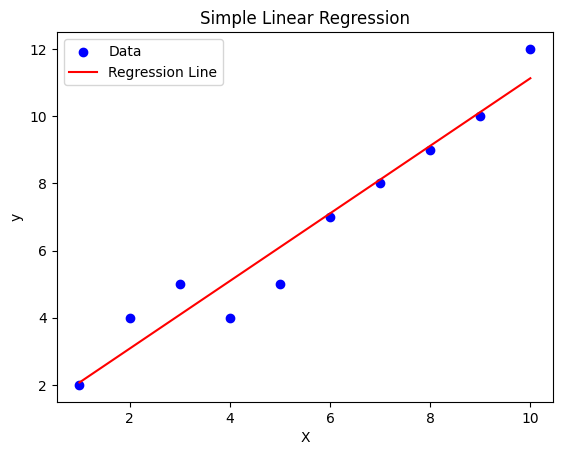

In [2]:
import numpy as np
import matplotlib.pyplot as plt
class SimpleLinearRegression:
    def __init__(self):
        self.coefficient_ = None
        self.intercept_ = None
        self.r2score_ = None

    def fit(self, X, y):
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X]

        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        y_pred = X_b.dot(self.coefficients_)
        # R²
        self.r2score_ = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred

    def predict(self, X):
        X_b = np.c_[np.ones((len(X),1)), X]
        return X_b.dot(self.coefficients_)
X_simple = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y_simple = np.array([2,4,5,4,5,7,8,9,10,12])

slr = SimpleLinearRegression()
slr.fit(X_simple, y_simple)


print(f"Simple LR Coefficients: {slr.coefficients_}")
print(f"R² Score: {slr.r2score_:.2f}")

plt.scatter(X_simple, y_simple, color='blue', label='Data')
plt.plot(X_simple, slr.y_pred_, color='red', label='Regression Line')
plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

**Locally Weighted Linear Regression (LWLR)** is a non-parametric machine learning algorithm where a distinct local model is fit for every specific query point. Instead of calculating a global boundary, it assigns higher weights to training data points that are closer to the target query point using a Gaussian kernel function.
• **No Training Phase:** LWLR is a lazy learner (similar to k-Nearest Neighbors). It does not calculate parameters until you explicitly ask it to predict a new point.
• **Computational Cost:** Because it relies on all training observations to perform a new matrix inversion for each unique query point, it can be computationally expensive on massive datasets.
• **Hyperparameter Tuning:** The parameter tau (\(\tau \)) controls the bandwidth. Setting it too low will capture noise (overfitting), while setting it too high behaves just like ordinary global linear regression (underfitting)

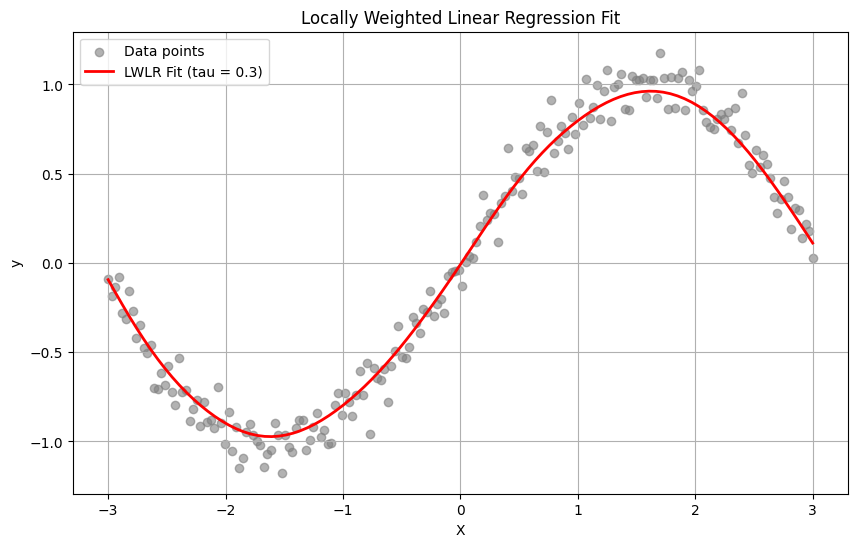

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Gaussian Kernel to calculate weights
def get_weight_matrix(query_point, X, tau):
    """
    Calculates a diagonal weight matrix for a given query point.
    Higher weights are assigned to training points closer to the query point.
    """
    m = X.shape[0]
    W = np.eye(m) # Initialize as an identity matrix

    for i in range(m):
        diff = query_point - X[i]
        # Gaussian kernel formula: w(i) = exp(-||x(i) - x||^2 / (2 * tau^2))
        W[i, i] = np.exp(np.dot(diff, diff.T) / (-2.0 * (tau ** 2)))

    return W

# 2. Predict the target value for a specific query point
def predict(X, y, query_point, tau):
    """
    Fits a local linear regression model for a single query point and returns its prediction.
    """
    # Number of training samples
    m = X.shape[0]

    # Add bias term (column of 1s) to the feature matrix
    X_biased = np.append(X, np.ones((m, 1)), axis=1)

    # Prepare the query point by adding a 1 for its bias term
    query_biased = np.array([query_point, 1.0], dtype=object)

    # Obtain the localized weight matrix
    W = get_weight_matrix(query_biased[:-1], X, tau)

    # Calculate local parameter theta using the normal equation: inv(X^T * W * X) * X^T * W * y
    # np.linalg.pinv is safer to use to prevent singular matrix errors
    theta = np.linalg.pinv(X_biased.T @ W @ X_biased) @ (X_biased.T @ W @ y)

    # Make the prediction: dot product of query point and theta
    prediction = np.dot(query_biased, theta)
    return prediction

# 3. Wrapper function to generate predictions across an evaluation space
def fit_data(X, y, evaluation_points, tau):
    """
    Iterates over all evaluation points to build the non-linear fitted curve.
    """
    predictions = []
    for point in evaluation_points:
        pred = predict(X, y, point, tau)
        predictions.append(pred)
    return np.array(predictions)

# ==========================================
# TEST IMPLEMENTATION WITH GENERATED DATA
# ==========================================
if __name__ == "__main__":
    # Generate noisy non-linear data (Sine Wave)
    np.random.seed(42)
    X = np.linspace(-3, 3, 200).reshape(-1, 1)
    y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

    # Define evaluation space for plotting the smooth curve
    X_eval = np.linspace(-3, 3, 100)

    # Test different values of the smoothing bandwidth parameter (tau)
    # A smaller tau creates a tighter fit (higher variance), larger tau smooths it out (higher bias)
    tau_value = 0.3
    y_pred = fit_data(X, y, X_eval, tau_value)

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='gray', alpha=0.6, label='Data points')
    plt.plot(X_eval, y_pred, color='red', linewidth=2, label=f'LWLR Fit (tau = {tau_value})')
    plt.title('Locally Weighted Linear Regression Fit')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()
